# Mortgage Rate vs. Sales Volume

This notebook explores whether the national 30-year fixed mortgage rate appears related to sold transaction volume.

Important note: this is exploratory analysis, not causal proof. Mortgage rates are only one factor affecting transaction volume.

## 1. Import Packages And Set Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "data" / "reports" / "mortgage_rate_vs_sales_volume"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SOLD_WITH_RATES_FILE = PROCESSED_DIR / "crmls_sold_combined_residential_with_mortgage_rates_202401_202605.csv"
SOLD_WITH_RATES_FILE

PosixPath('/Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/processed/crmls_sold_combined_residential_with_mortgage_rates_202401_202605.csv')

## 2. Load Enriched Sold Dataset

In [2]:
sold = pd.read_csv(SOLD_WITH_RATES_FILE, low_memory=False)

print(f"Rows: {sold.shape[0]:,}")
print(f"Columns: {sold.shape[1]:,}")
sold[["CloseDate", "year_month", "ClosePrice", "rate_30yr_fixed"]].head()

Rows: 430,454
Columns: 84


,CloseDate,year_month,ClosePrice,rate_30yr_fixed
0,2024-01-26,2024-01,240000.0,6.6425
1,2024-01-05,2024-01,815000.0,6.6425
2,2024-01-05,2024-01,810000.0,6.6425
3,2024-01-02,2024-01,2100000.0,6.6425
4,2024-01-22,2024-01,1950000.0,6.6425


## 3. Validate Mortgage Rate Merge

In [3]:
print("Missing mortgage rates:", sold["rate_30yr_fixed"].isna().sum())
print("Missing year_month:", sold["year_month"].isna().sum())

sold[["year_month", "rate_30yr_fixed"]].drop_duplicates().sort_values("year_month").head()

Missing mortgage rates: 0
Missing year_month: 0


,year_month,rate_30yr_fixed
0,2024-01,6.6425
11194,2024-02,6.7760
24257,2024-03,6.8200
40041,2024-04,6.9925
57336,2024-05,7.0600


## 4. Create Monthly Sales Volume

成交量 here means the number of Residential sold records per month.

In [4]:
sold["CloseDateParsed"] = pd.to_datetime(sold["CloseDate"], errors="coerce")
sold["year_month"] = sold["CloseDateParsed"].dt.to_period("M").astype(str)

monthly_volume = (
    sold.dropna(subset=["CloseDateParsed", "rate_30yr_fixed"])
    .groupby("year_month")
    .agg(
        sales_volume=("ListingKey", "size"),
        rate_30yr_fixed=("rate_30yr_fixed", "mean"),
        median_close_price=("ClosePrice", "median"),
    )
    .reset_index()
)

monthly_volume["month_date"] = pd.to_datetime(monthly_volume["year_month"] + "-01")
monthly_volume = monthly_volume.sort_values("month_date")

monthly_volume

,year_month,sales_volume,rate_30yr_fixed,median_close_price,month_date
0,2024-01,11194,6.6425,749000.0,2024-01-01
1,2024-02,13063,6.7760,790000.0,2024-02-01
2,2024-03,15784,6.8200,810000.0,2024-03-01
3,2024-04,17295,6.9925,850000.0,2024-04-01
4,2024-05,18474,7.0600,856500.0,2024-05-01
5,2024-06,16625,6.9175,855000.0,2024-06-01
6,2024-07,17809,6.8475,850000.0,2024-07-01
7,2024-08,16791,6.5000,830000.0,2024-08-01
8,2024-09,14555,6.1800,822240.0,2024-09-01
9,2024-10,16275,6.4280,849000.0,2024-10-01


## 5. Plot Mortgage Rate And Sales Volume Over Time

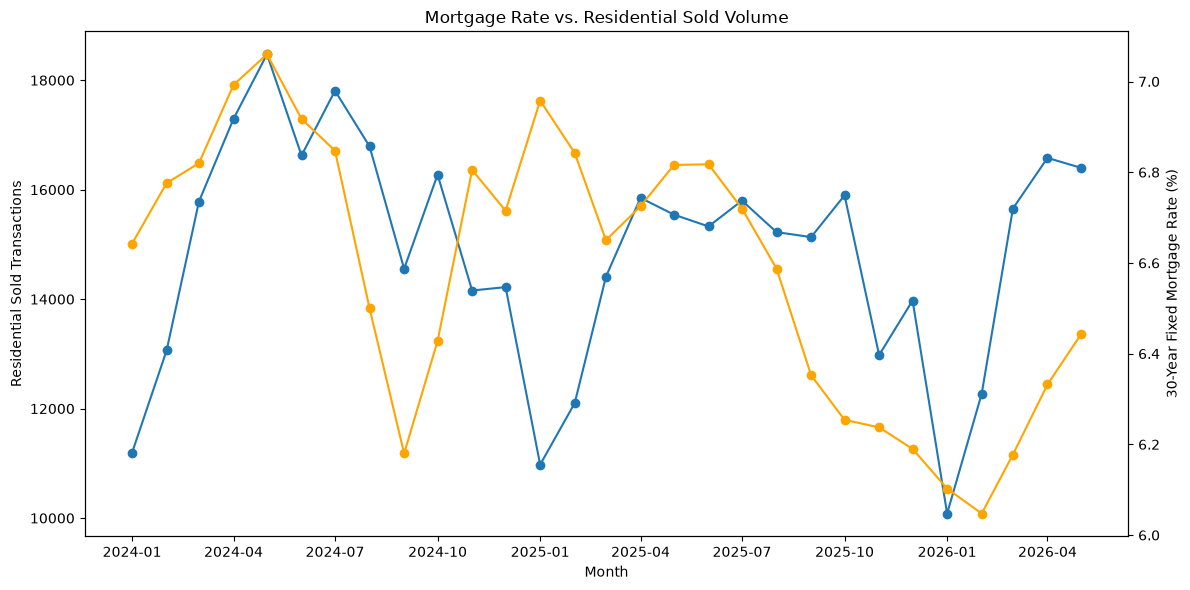

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_volume["month_date"],
    monthly_volume["sales_volume"],
    marker="o",
    label="Sales Volume",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Residential Sold Transactions")

ax2 = ax1.twinx()
ax2.plot(
    monthly_volume["month_date"],
    monthly_volume["rate_30yr_fixed"],
    color="orange",
    marker="o",
    label="30-Year Fixed Mortgage Rate",
)
ax2.set_ylabel("30-Year Fixed Mortgage Rate (%)")

plt.title("Mortgage Rate vs. Residential Sold Volume")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "mortgage_rate_vs_sales_volume_time_series.png")
plt.show()

## 6. Correlation Check

A negative correlation would mean that higher mortgage rates are associated with lower sales volume in this period. This does not prove rates caused the volume change.

In [6]:
same_month_corr = monthly_volume["rate_30yr_fixed"].corr(monthly_volume["sales_volume"])

monthly_volume["rate_lag_1_month"] = monthly_volume["rate_30yr_fixed"].shift(1)
monthly_volume["rate_lag_2_months"] = monthly_volume["rate_30yr_fixed"].shift(2)

lag_1_corr = monthly_volume["rate_lag_1_month"].corr(monthly_volume["sales_volume"])
lag_2_corr = monthly_volume["rate_lag_2_months"].corr(monthly_volume["sales_volume"])

correlation_summary = pd.DataFrame([
    {"comparison": "same_month_rate_vs_sales_volume", "correlation": same_month_corr},
    {"comparison": "prior_1_month_rate_vs_sales_volume", "correlation": lag_1_corr},
    {"comparison": "prior_2_month_rate_vs_sales_volume", "correlation": lag_2_corr},
])

correlation_summary

,comparison,correlation
0,same_month_rate_vs_sales_volume,0.280801
1,prior_1_month_rate_vs_sales_volume,0.309008
2,prior_2_month_rate_vs_sales_volume,0.319138


## 7. Scatter Plot

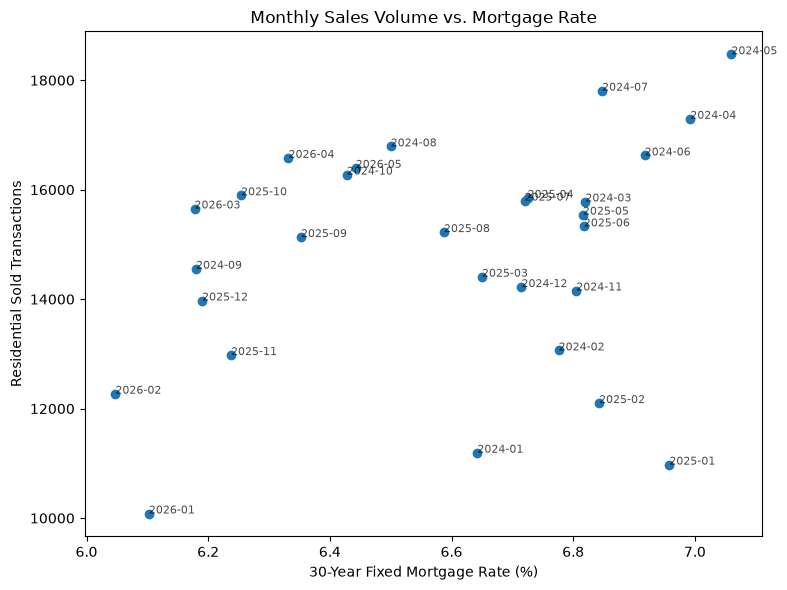

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(monthly_volume["rate_30yr_fixed"], monthly_volume["sales_volume"])

for _, row in monthly_volume.iterrows():
    plt.annotate(
        row["year_month"],
        (row["rate_30yr_fixed"], row["sales_volume"]),
        fontsize=8,
        alpha=0.7,
    )

plt.title("Monthly Sales Volume vs. Mortgage Rate")
plt.xlabel("30-Year Fixed Mortgage Rate (%)")
plt.ylabel("Residential Sold Transactions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sales_volume_vs_mortgage_rate_scatter.png")
plt.show()

## 8. Compare High-Rate Months Vs. Low-Rate Months

This splits months into above-median and below-median mortgage rate groups, then compares average sales volume.

In [8]:
median_rate = monthly_volume["rate_30yr_fixed"].median()

monthly_volume["rate_group"] = monthly_volume["rate_30yr_fixed"].apply(
    lambda value: "High-rate months" if value >= median_rate else "Low-rate months"
)

rate_group_summary = (
    monthly_volume.groupby("rate_group")
    .agg(
        month_count=("year_month", "size"),
        average_rate=("rate_30yr_fixed", "mean"),
        average_sales_volume=("sales_volume", "mean"),
        median_sales_volume=("sales_volume", "median"),
    )
    .reset_index()
)

rate_group_summary

,rate_group,month_count,average_rate,average_sales_volume,median_sales_volume
0,High-rate months,15,6.830833,15162.533333,15544.0
1,Low-rate months,14,6.319571,14501.142857,15179.5


## 9. Save Outputs

In [9]:
monthly_volume.to_csv(REPORT_DIR / "monthly_sales_volume_with_mortgage_rates.csv", index=False)
correlation_summary.to_csv(REPORT_DIR / "mortgage_rate_sales_volume_correlation.csv", index=False)
rate_group_summary.to_csv(REPORT_DIR / "high_vs_low_rate_month_sales_volume.csv", index=False)

print("Saved reports to:", REPORT_DIR)
print("Saved figures to:", FIGURE_DIR)

Saved reports to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/mortgage_rate_vs_sales_volume
Saved figures to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/mortgage_rate_vs_sales_volume/figures


## 10. Interpretation

Use the tables and charts above to write a cautious summary:

> I aggregated Residential sold records by close month and compared monthly sales volume with the monthly average 30-year fixed mortgage rate. The correlation table shows whether higher rates were associated with higher or lower transaction volume during this period. This is an exploratory relationship, not causal proof, because sales volume is also affected by seasonality, inventory, local demand, pricing, and broader economic conditions.